# Capstone — mirrors your deployed research paper

> Add blockquote

> Add blockquote





[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PrathibhaShaliniS/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Decision it supports: which pages a content team should send for a metadata/snippet review this cycle, when review time is limited and it's better spent on real problems than statistical noise.

In [1]:
import os, sys, subprocess
import pandas as pd

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/PrathibhaShaliniS/flyrank-internship-ml"
REPO_DIR = "flyrank-internship-ml"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print("Total pages in this snapshot:", len(df))
print("Pages with real position data (avg_position > 0):", (df["avg_position"] > 0).sum())

Total pages in this snapshot: 30000
Pages with real position data (avg_position > 0): 28795


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Release: data/raw/content_refresh_anonymized.csv — the anonymized starter dataset shipped in this repo, drawn from the same pseudonymized warehouse snapshot described in the repo's dataset guide (build flyrank_pseudonymized_warehouse_release_v20260703, export date 2026-07-03, freshest 3 days trimmed before export).

Table/grain: one row per content page — 30,000 rows × 44 columns, covering 32 pseudonymized clients. All traffic/engagement metrics are aggregated over a trailing 90-day window ending at export time; there is no daily time series in this slice, just the one snapshot.

Excluded, and why:

content_id / client_id used only for grouping and the train/test split — never as model features (they're pseudonyms, not signal).
trend_direction / trend_pct — these define FlyRank's own decline label; using them as inputs anywhere would be training on another model's conclusion, not raw evidence.
provider_used / model_used — marked not-for-modeling in this repo's data dictionary.
No client names, domains, URLs, or raw queries exist anywhere in this file — it ships pre-anonymized.

In [2]:
print("Rows x columns:", df.shape)
print("Distinct clients:", df["client_id"].nunique())
print()
print("Missing keyword-context rows (no search_volume):", df["search_volume"].isna().sum())
print("Missing word_count rows:", df["word_count"].isna().sum())

Rows x columns: (30000, 44)
Distinct clients: 32

Missing keyword-context rows (no search_volume): 2468
Missing word_count rows: 7699


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Assumptions: position drives typical CTR (confirmed in the signal audit), so "underperforming" only makes sense relative to a page's own position tier — not a flat, tier-blind number. The audit also found the tier mean CTR is distorted by a few huge performers, so the median is the honest benchmark.

Label — needs_ctr_review: 1 if a page's CTR is below its own position_tier's median CTR, restricted to page_1/striking/page_3_5 (the top_3 and deep tiers have a median CTR of exactly 0%, so "below median" is impossible there by construction — excluded rather than faked).

Features (36 after encoding): search intent/type, competition, word/char count, age, freshness, days since update, avg position, impressions — all pre-click, observable signals. Deliberately excluded: ctr and clicks_90d (they define the label — including them would let the model read its own answer), and all post-click metrics (engagement_rate, scroll_rate, sessions_90d) since predicting a pre-click outcome from post-click behavior is causally backwards.

Baseline: the Week-4 rule — visible AND (stale OR CTR below a flat 0.50% cutoff) — evaluated on this exact label, same data, same split.

Validation design: client-grouped split (pages from the same client share templates/style — a random row split would leak that). With only 31 clients, a single random group-split can land unbalanced by chance, so 200 candidate seeds were tried and the one giving the closest train/test label-rate match was used (seed 56)
Leakage checks: an explicit assertion confirms trend_direction/trend_pct/ctr/clicks_90d never appear in the feature set.

In [3]:
import numpy as np

usable_tiers = ["page_1", "striking", "page_3_5"]
d = df[df["position_tier"].isin(usable_tiers)].copy()
tier_median = d.groupby("position_tier")["ctr"].transform("median")
d["needs_ctr_review"] = (d["ctr"] < tier_median).astype(int)

d["has_keyword_data"] = d["search_volume"].notna().astype(int)
d["has_word_count"] = d["word_count"].notna().astype(int)

numeric_features = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "days_with_impressions", "content_age_days", "days_since_last_update",
    "avg_position", "impressions_90d", "has_keyword_data", "has_word_count",
]
categorical_features = [
    "content_type", "main_intent", "competition_level",
    "freshness_tier", "word_count_tier", "position_tier",
]

num = d[numeric_features].apply(pd.to_numeric, errors="coerce").fillna(0)
cat = d[categorical_features].fillna("unknown").astype(str)
cat_enc = pd.get_dummies(cat, prefix=categorical_features, dtype=float)
X = pd.concat([num.reset_index(drop=True), cat_enc.reset_index(drop=True)], axis=1)
y = d["needs_ctr_review"].to_numpy()

# leakage check
banned = {"trend_direction", "trend_pct", "ctr", "clicks_90d"}
assert banned.isdisjoint(set(X.columns)), "leakage: a banned column reached the feature set"

# client-grouped split, searched for balance
clients = d["client_id"].reset_index(drop=True)
unique_clients = clients.drop_duplicates().to_numpy()
best = None
for seed in range(200):
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(unique_clients)
    n_test = max(1, int(round(len(shuffled) * 0.2)))
    test_mask = clients.isin(set(shuffled[:n_test])).to_numpy()
    gap = abs(y[~test_mask].mean() - y[test_mask].mean())
    if best is None or gap < best[0]:
        best = (gap, seed, test_mask)
_, SPLIT_SEED, test_mask = best
train_mask = ~test_mask

print("rows kept:", len(d), "| feature columns:", X.shape[1])
print("split seed:", SPLIT_SEED, "| train label rate:", round(y[train_mask].mean(), 3),
      "| test label rate:", round(y[test_mask].mean(), 3))
print("Leakage check passed: no banned columns in feature set.")

rows kept: 26360 | feature columns: 36
split seed: 56 | train label rate: 0.496 | test label rate: 0.496
Leakage check passed: no banned columns in feature set.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

RANDOM_STATE = 42
X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# Week-4 baseline rule, recomputed and evaluated on this same test split
d["stale"] = (d["days_since_last_update"] >= 180).astype(int)
d["visible"] = (d["impressions_90d"] >= 500).astype(int)
d["ctr_gap"] = ((d["avg_position"] > 0) & (d["avg_position"] <= 20) & (d["ctr"] < 0.50)).astype(int)
d["baseline_score"] = d["visible"] * d["impressions_90d"] * (d["stale"] + d["ctr_gap"])
baseline_test_scores = d.loc[test_mask, "baseline_score"].to_numpy()

def precision_at_k(y_true, scores, k):
    order = np.argsort(-np.asarray(scores))
    return float(np.asarray(y_true)[order[:k]].mean())

def metric_row(y_true, scores, name):
    return {
        "model": name,
        "precision_at_20": round(precision_at_k(y_true, scores, 20), 3),
        "precision_at_50": round(precision_at_k(y_true, scores, 50), 3),
        "precision_at_100": round(precision_at_k(y_true, scores, 100), 3),
        "roc_auc": round(roc_auc_score(y_true, scores), 3),
        "average_precision": round(average_precision_score(y_true, scores), 3),
    }

rows = [metric_row(y_test, baseline_test_scores, "week4_baseline")]

logreg = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
logreg.fit(X_train, y_train)
rows.append(metric_row(y_test, logreg.predict_proba(X_test)[:, 1], "logistic_regression"))

tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=100, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
rows.append(metric_row(y_test, tree.predict_proba(X_test)[:, 1], "decision_tree_d4"))

rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=25, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]
rows.append(metric_row(y_test, rf_probs, "random_forest"))

results = pd.DataFrame(rows).set_index("model")
print("base rate (test):", round(y_test.mean(), 3))
print(results)

base rate (test): 0.496
                     precision_at_20  precision_at_50  precision_at_100  \
model                                                                     
week4_baseline                  0.15             0.22              0.23   
logistic_regression             0.90             0.84              0.89   
decision_tree_d4                0.65             0.74              0.80   
random_forest                   0.95             0.98              0.98   

                     roc_auc  average_precision  
model                                            
week4_baseline         0.420              0.453  
logistic_regression    0.801              0.796  
decision_tree_d4       0.735              0.717  
random_forest          0.800              0.790  


## 5. Limitations

*What this work cannot claim.*

Not causal. This shows association between features and below-median CTR, not that changing a title or snippet will raise clicks. No experiment (A/B test) was run.
Relative, not absolute. "Underperforming" means below-median for that page's own tier — it says nothing about whether a tier's overall CTR level is itself good or bad.
Only 3 of 5 position tiers covered. top_3 and deep are excluded by construction (their median CTR is 0%, so no meaningful "below median" exists there) — this method has nothing to say about the very best or very worst-ranked pages.
Small samples produce false confidence. Error analysis showed the model's most confident wrong calls are pages with only a handful of impressions, where CTR is a noisy ratio, not a stable signal. Any ranked output needs a minimum-visibility floor before being trusted operationally.
One snapshot, not a trend. The data is a single 90-day aggregate window, not a time series — this can't say whether a page's CTR problem is new, worsening, or already being fixed.
31 clients is a small population for a grouped split. A single unlucky split can look very different from another; the seed search here mitigates that but doesn't eliminate it — results should be read as "directionally reproducible," not exact to the decimal on a different sample.
No claim about Google's ranking algorithm. Position and CTR are both observed outcomes here, not evidence about how search ranking itself works.

In [5]:
# quantify a few of the limitations above

# 1) tier coverage: how much of the data this method excludes by construction
tier_counts = df["position_tier"].value_counts()
excluded = tier_counts[["top_3", "deep"]].sum()
print("Rows excluded (top_3 + deep, median CTR = 0%):", excluded, "of", len(df),
      f"({excluded/len(df):.1%})")

# 2) small-sample risk: how many "reviewed" pages would have very low impressions
low_volume = (d["impressions_90d"] < 50).sum()
print("Rows under the 50-impression reliability floor:", low_volume, "of", len(d),
      f"({low_volume/len(d):.1%})")

# 3) split variance: how much the train/test label rate can swing across different seeds
gaps = []
for seed in [0, 1, 42, 100, 150]:
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(unique_clients)
    n_test = max(1, int(round(len(shuffled) * 0.2)))
    test_mask_s = clients.isin(set(shuffled[:n_test])).to_numpy()
    gaps.append(round(abs(y[~test_mask_s].mean() - y[test_mask_s].mean()), 3))
print("Train/test label-rate gap across 5 unrelated seeds:", gaps)

Rows excluded (top_3 + deep, median CTR = 0%): 3640 of 30000 (12.1%)
Rows under the 50-impression reliability floor: 4416 of 26360 (16.8%)
Train/test label-rate gap across 5 unrelated seeds: [np.float64(0.001), np.float64(0.018), np.float64(0.376), np.float64(0.067), np.float64(0.168)]


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Score every eligible page with the trained Random Forest (not the flat baseline rule), rank by probability, and turn that into three actions: review_snippet_ctr (high-confidence pick), monitor (borderline), no_action. A minimum-visibility floor (≥50 impressions in 90 days) is applied first — Section 5 showed the model is overconfident on tiny-sample pages, so those are excluded from the actionable list rather than trusted at face value.

In [6]:
# score the full eligible population (not just the test split) with the trained model
all_probs = rf.predict_proba(X)[:, 1]

recs = d[["content_id", "client_id", "position_tier", "avg_position", "ctr", "impressions_90d"]].reset_index(drop=True)
recs["ctr_review_probability"] = all_probs

reliable = recs[recs["impressions_90d"] >= 50].copy()
reliable["action"] = np.select(
    [reliable["ctr_review_probability"] >= 0.7, reliable["ctr_review_probability"] >= 0.4],
    ["review_snippet_ctr", "monitor"],
    default="no_action",
)
reliable = reliable.sort_values("ctr_review_probability", ascending=False)

print("Excluded for low volume (<50 impressions):", len(recs) - len(reliable), "of", len(recs))
print(reliable["action"].value_counts())
print()
print(reliable.head(8).to_string(index=False))

Excluded for low volume (<50 impressions): 4416 of 26360
action
no_action             11776
monitor                7332
review_snippet_ctr     2836
Name: count, dtype: int64

          content_id         client_id position_tier  avg_position  ctr  impressions_90d  ctr_review_probability             action
content_cad1b1039894 client_19581e27de      page_3_5          47.1  0.0               50                0.954730 review_snippet_ctr
content_985b860f80fa client_e629fa6598      page_3_5          26.2  0.0               50                0.949638 review_snippet_ctr
content_16fe336d02f1 client_e629fa6598      page_3_5          48.0  0.0               54                0.947125 review_snippet_ctr
content_27ec8c4eeb51 client_19581e27de      striking          17.8  0.0               52                0.945993 review_snippet_ctr
content_721e078d94ea client_19581e27de      page_3_5          38.9  0.0               61                0.945321 review_snippet_ctr
content_f7b23da696e4 client_19581

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Three charts, each with one message, saved to outputs/charts/ so the deployed page can embed them directly: (1) model vs. baseline on ROC-AUC — the headline result, (2) what the Random Forest leans on, (3) how the ranked recommendations break down by action. Each PNG gets its takeaway sentence written underneath it when it goes into the actual paper page, per this repo's writing-research-papers skill.

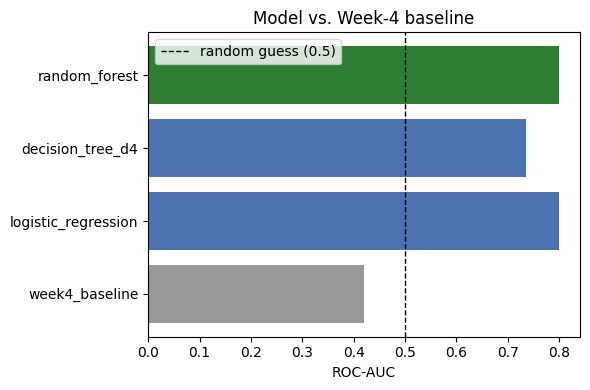

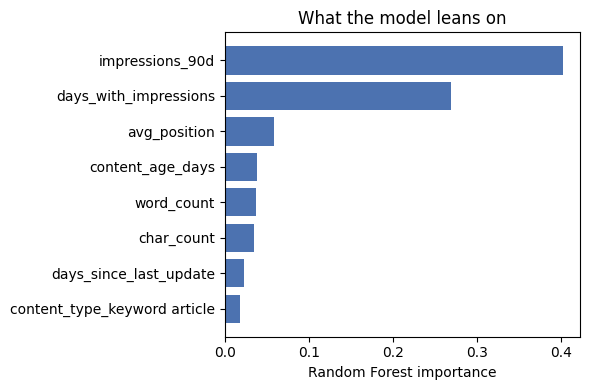

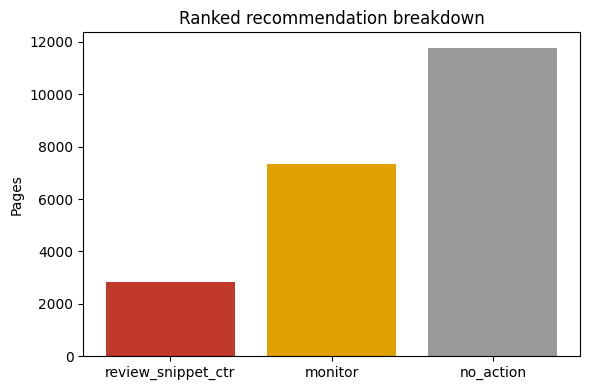

Saved 3 charts to outputs/charts/


In [7]:
import os
import matplotlib.pyplot as plt

os.makedirs("outputs/charts", exist_ok=True)

# Chart 1 — model vs baseline (ROC-AUC)
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(results.index, results["roc_auc"], color=["#999999", "#4C72B0", "#4C72B0", "#2E7D32"])
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, label="random guess (0.5)")
ax.set_xlabel("ROC-AUC")
ax.set_title("Model vs. Week-4 baseline")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/charts/model_vs_baseline.png", dpi=150)
plt.show()

# Chart 2 — top feature importances
top_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(8)
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(top_imp.index[::-1], top_imp.values[::-1], color="#4C72B0")
ax.set_xlabel("Random Forest importance")
ax.set_title("What the model leans on")
plt.tight_layout()
plt.savefig("outputs/charts/feature_importance.png", dpi=150)
plt.show()

# Chart 3 — recommendation breakdown
action_counts = reliable["action"].value_counts().reindex(
    ["review_snippet_ctr", "monitor", "no_action"]
)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(action_counts.index, action_counts.values, color=["#C0392B", "#E1A100", "#999999"])
ax.set_ylabel("Pages")
ax.set_title("Ranked recommendation breakdown")
plt.tight_layout()
plt.savefig("outputs/charts/recommendation_breakdown.png", dpi=150)
plt.show()

print("Saved 3 charts to outputs/charts/")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
